2026-06-20 19:58:11.721 | INFO     | skclust.neighbors:fit:1238 - Auto-detected curve shape: direction=increasing, curve=concave
2026-06-20 19:58:11.721 | INFO     | skclust.neighbors:fit:1252 - Auto k=16 (knee detection, sensitivity=1.0)
2026-06-20 19:58:11.724 | INFO     | skclust.neighbors:fit:1264 - SNN graph: 500 nodes, 5881 edges
2026-06-20 19:58:11.753 | INFO     | skclust.neighbors:fit:1255 - User-specified k=20
2026-06-20 19:58:11.757 | INFO     | skclust.neighbors:fit:1264 - SNN graph: 500 nodes, 7196 edges
2026-06-20 19:58:11.778 | INFO     | skclust.neighbors:fit:1255 - User-specified k=20
2026-06-20 19:58:11.782 | INFO     | skclust.neighbors:fit:1264 - SNN graph: 500 nodes, 7196 edges


labels_: ['genome_0', 'genome_1', 'genome_2', 'genome_3', 'genome_4']
similarities_ shape: (500, 50)
indices_ shape: (500, 50)
Self-similarity (should be ~1.0): 1.0000
Auto k: 16
Graph: 500 nodes, 5881 edges
Vertex names sample: ['genome_0', 'genome_1', 'genome_2', 'genome_3', 'genome_4']
k=20: 500 nodes, 7196 edges
k=10: 500 nodes, 3810 edges
k=20: 500 nodes, 7196 edges
k=30: 500 nodes, 10307 edges
Clusters: 5
Labels sample:
Node
genome_0    leiden_1
genome_1    leiden_2
genome_2    leiden_1
genome_3    leiden_1
genome_4    leiden_1
Name: Cluster, dtype: object
Unstable nodes: 0


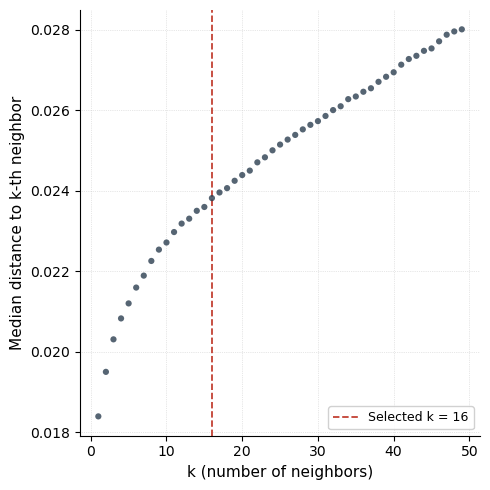

In [1]:
# Cell 1: Synthetic data
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.datasets import make_blobs
from loguru import logger

X_raw, y_true = make_blobs(n_samples=500, n_features=64, centers=5, random_state=0)
X_l2 = pd.DataFrame(
    normalize(X_raw, norm="l2"),
    index=[f"genome_{i}" for i in range(500)],
)

# Cell 2: KNeighborsCosineGraph
from skclust.neighbors import KNeighborsCosineGraph

knn = KNeighborsCosineGraph(n_neighbors=50)
knn.fit(X_l2)

print(f"labels_: {knn.labels_[:5].tolist()}")
print(f"similarities_ shape: {knn.similarities_.shape}")
print(f"indices_ shape: {knn.indices_.shape}")
print(f"Self-similarity (should be ~1.0): {knn.similarities_[0, 0]:.4f}")

# Cell 3: SharedNearestNeighborsGraph — auto k
from skclust.neighbors import SharedNearestNeighborsGraph

snn = SharedNearestNeighborsGraph.from_kneighbors_cosine_graph(knn)
snn.fit()

print(f"Auto k: {snn.k_}")
print(f"Graph: {snn.graph_.vcount()} nodes, {snn.graph_.ecount()} edges")
print(f"Vertex names sample: {snn.graph_.vs['name'][:5]}")

# Cell 4: Plot knee
snn.plot_knee()

# Cell 5: Specified k
snn2 = SharedNearestNeighborsGraph.from_kneighbors_cosine_graph(knn, k=20)
graph = snn2.fit_transform()
print(f"k=20: {graph.vcount()} nodes, {graph.ecount()} edges")

# Cell 6: Parameter sweep (stateless)
for k in [10, 20, 30]:
    graph = snn.to_igraph(k=k)
    print(f"k={k}: {graph.vcount()} nodes, {graph.ecount()} edges")

# Cell 7: Full pipeline with Leiden
from skclust.graph import ConsensusLeidenClustering
from leidenalg import CPMVertexPartition

graph = SharedNearestNeighborsGraph.from_kneighbors_cosine_graph(knn, k=20).fit_transform()

leiden = ConsensusLeidenClustering(
    resolution_parameter=0.01,
    partition_type=CPMVertexPartition,
    weight="weight",
    n_iter=10,
    n_jobs=1,
)
leiden.fit(graph)

print(f"Clusters: {leiden.n_clusters_}")
print(f"Labels sample:\n{leiden.labels_.head()}")
print(f"Unstable nodes: {len(leiden.unstable_nodes_)}")